<a href="https://colab.research.google.com/github/uctharun/COMPUTER-VISION/blob/main/EX%2025%20Sharpening%20of%20Image%20using%20Gradient%20masking%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
import cv2
import matplotlib.pyplot as plt

In [47]:
from google.colab import files

uploaded = files.upload()


Saving tiger.jfif to tiger (1).jfif


In [48]:
filename = next(iter(uploaded))
image = cv2.imread(filename)

print("Image loaded successfully!")

Image loaded successfully!


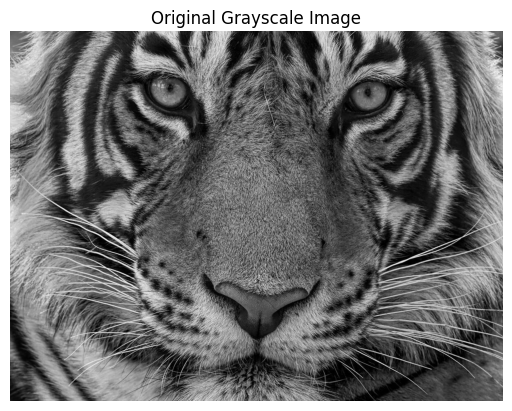

In [49]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")
plt.show()

In [50]:
gradient_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
gradient_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

In [51]:
gradient_magnitude = cv2.magnitude(
    gradient_x.astype(np.float32),
    gradient_y.astype(np.float32)
)

gradient_magnitude = cv2.normalize(
    gradient_magnitude,
    None,
    0,
    255,
    cv2.NORM_MINMAX
)

gradient_magnitude = gradient_magnitude.astype(np.uint8)

In [52]:
sharpened = cv2.add(
    gray,
    gradient_magnitude
)

sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)

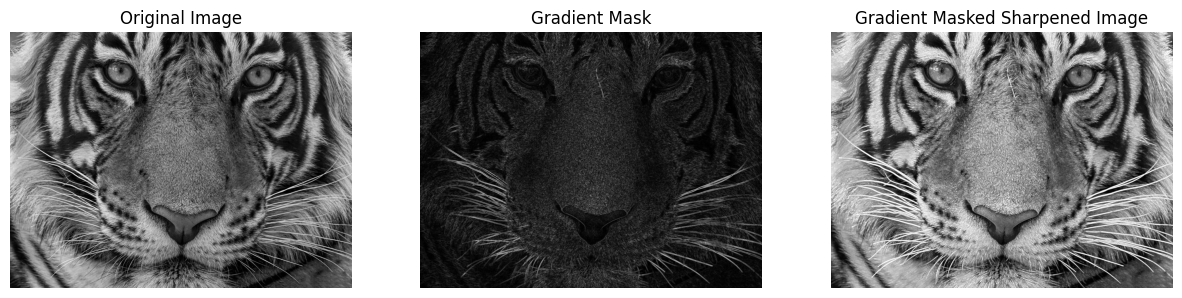

In [53]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(gray, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gradient_magnitude, cmap="gray")
plt.title("Gradient Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(sharpened, cmap="gray")
plt.title("Gradient Masked Sharpened Image")
plt.axis("off")

plt.show()